In [ ]:
!pip uninstall torch torchvision -y
!pip cache purge
!pip install torch torchvision numpy==1.26.4 --no-cache-dir

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Files removed: 0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 295.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.2/821.2 MB 185.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 261.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 311.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 266.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 406.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 260.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 254.4 MB/s et

In [1]:
!pip uninstall torch torchvision torchaudio fastai thinc spacy numpy torchcam tensorflow numba timm -y
!pip cache purge
!pip install torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 fastai==2.7.19 thinc==8.2.5 spacy==3.7.5 numpy==1.26.4 torchcam==0.4.0 tensorflow==2.18.0 numba==0.60.0 timm --no-cache-dir

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124
Found existing installation: fastai 2.7.19
Uninstalling fastai-2.7.19:
  Successfully uninstalled fastai-2.7.19
Found existing installation: thinc 8.3.6
Uninstalling thinc-8.3.6:
  Successfully uninstalled thinc-8.3.6
Found existing installation: spacy 3.8.7
Uninstalling spacy-3.8.7:
  Successfully uninstalled spacy-3.8.7
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: tensorflow 2.18.0
Uninstalling tensorflow-2.18.0:
  Successfully uninstalled tensorflow-2.18.0
Found existing installation: numba 0.6

In [1]:
!pip show torch
!pip show torchvision
!pip show numpy

Name: torch
Version: 2.6.0
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: /usr/local/lib/python3.11/dist-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvtx-cu12, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchaudio, torchcam, torchdata, torchvision
Name: torchvision
Version: 0.21.0
Summary: image and video datasets and models for torch deep learning
Home-page: https://github.com/pytorch/vision
Author: PyTorch Core Team
Author-email: soumith@pytorch.org
License: BSD
Location: /usr/local/lib/python3.11/d

In [2]:
import torch
# ---------------------- 2. Device Configuration ----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)
if device.type == 'cuda':
    print("🚀 GPU Name:", torch.cuda.get_device_name(0))
else:
    print("⚠️ WARNING: GPU not available, training on CPU")

✅ Using device: cuda
🚀 GPU Name: Tesla T4


In [3]:
import kagglehub
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

# Download the dataset
path = kagglehub.dataset_download("ninadaithal/imagesoasis")
print("Path to dataset files:", path)

# Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load dataset
dataset = datasets.ImageFolder(root=path, transform=transform)

# Split dataset
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_ds, val_ds, test_ds = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])

# Dataloaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

Path to dataset files: /kaggle/input/imagesoasis


In [4]:
import torch.nn as nn
from torchvision.models import resnet18

# Load a pretrained ResNet18 model
model = resnet18(pretrained=True)

# Modify the final classification layer to match your dataset (3 classes)
model.fc = nn.Linear(model.fc.in_features, 3)

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


In [5]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [6]:
def train(model, train_loader, val_loader, criterion, optimizer, epochs=5):
    for epoch in range(epochs):
        model.train()
        train_loss, correct = 0.0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

        train_acc = correct / len(train_loader.dataset)

        # Validation
        model.eval()
        val_correct = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")


In [7]:
train(model, train_loader, val_loader, criterion, optimizer, epochs=2)

Epoch 1: Train Loss=18.6619, Train Acc=0.9966, Val Acc=1.0000
Epoch 2: Train Loss=0.1931, Train Acc=1.0000, Val Acc=1.0000


In [8]:
def test(model, test_loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            correct += (outputs.argmax(1) == labels).sum().item()

    accuracy = correct / len(test_loader.dataset)
    print(f"Test Accuracy: {accuracy:.4f}")

test(model, test_loader)


Test Accuracy: 1.0000


In [9]:
!pip install grad-cam --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 82.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


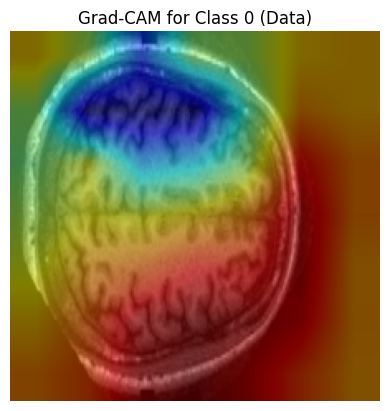

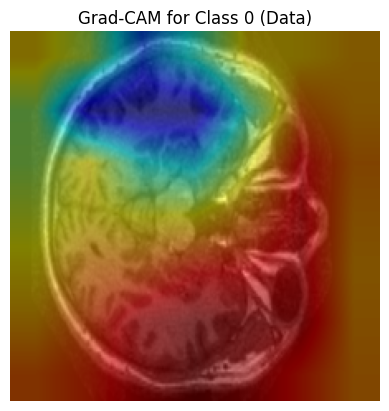

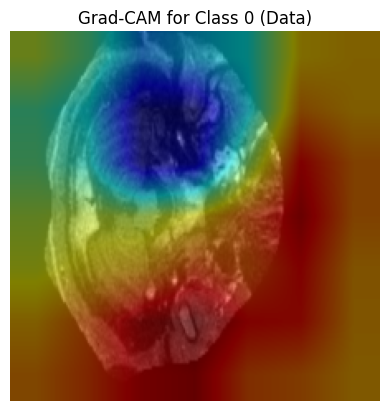

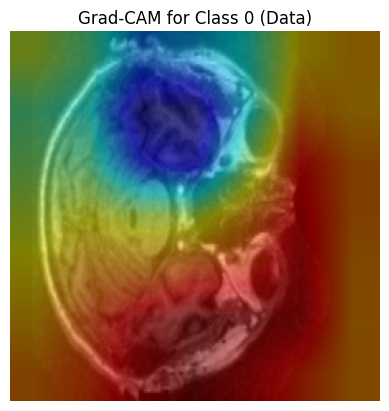

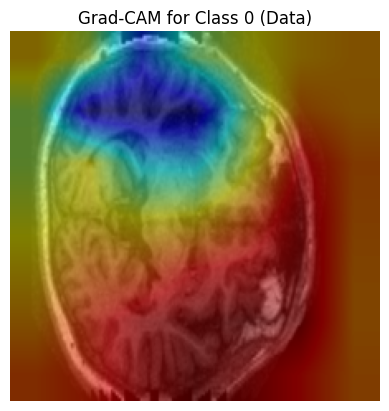

In [10]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import matplotlib.pyplot as plt

# Set up Grad-CAM
model.eval()
model.to(device)
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# Get one batch
images, labels = next(iter(test_loader))

# Loop through first 5 images in the batch
for i in range(5):
    input_tensor = images[i].unsqueeze(0).to(device)
    label = labels[i].item()

    # Normalize image for visualization
    rgb_image = images[i].permute(1, 2, 0).cpu().numpy()
    rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())

    # Run Grad-CAM
    targets = [ClassifierOutputTarget(label)]
    grayscale_cam = cam(input_tensor=input_tensor)[0]

    # Overlay heatmap
    visualization = show_cam_on_image(rgb_image, grayscale_cam, use_rgb=True)

    # Show image
    plt.imshow(visualization)
    plt.title(f"Grad-CAM for Class {label} ({dataset.classes[label]})")
    plt.axis('off')
    plt.show()


In [11]:
import torch
import torch.nn as nn
from torchvision import models
from einops import rearrange, repeat

class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super(TransformerEncoderBlock, self).__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout),
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_output, _ = self.attn(x, x, x)
        x = x + attn_output
        x = self.norm1(x)
        mlp_output = self.mlp(x)
        x = x + mlp_output
        x = self.norm2(x)
        return x

class CNNTransformerHybrid(nn.Module):
    def __init__(self, num_classes=3, embed_dim=512, num_heads=8, mlp_dim=2048, num_layers=1):
        super(CNNTransformerHybrid, self).__init__()
        # CNN backbone (use ResNet18 till layer4)
        resnet = models.resnet18(pretrained=True)
        self.cnn = nn.Sequential(*list(resnet.children())[:-2])  # output: [B, 512, 7, 7]

        self.flatten = nn.Flatten(2)  # [B, 512, 49]
        self.transpose = lambda x: x.permute(2, 0, 1)  # [49, B, 512]

        # Transformer encoder
        self.transformer_layers = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim) for _ in range(num_layers)
        ])

        # Classification head
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        x = self.cnn(x)  # [B, 512, 7, 7]
        x = self.flatten(x)  # [B, 512, 49]
        x = self.transpose(x)  # [49, B, 512]

        for layer in self.transformer_layers:
            x = layer(x)

        x = x.mean(dim=0)  # Global average pooling across sequence
        x = self.head(x)  # [B, num_classes]
        return x


In [12]:
model = CNNTransformerHybrid(num_classes=3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [13]:
import torch.optim as optim
import torch.nn as nn

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [14]:
train(model, train_loader, val_loader, criterion, optimizer, epochs=2)

Epoch 1: Train Loss=1.3028, Train Acc=0.9998, Val Acc=1.0000
Epoch 2: Train Loss=0.0027, Train Acc=1.0000, Val Acc=1.0000


In [15]:
test(model, test_loader)

Test Accuracy: 1.0000


In [16]:
torch.save(model.state_dict(), "cnn_transformer_hybrid.pth")

In [17]:
import torch
import torch.nn as nn
from torchvision import models
from einops import rearrange, repeat
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super(TransformerEncoderBlock, self).__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout),
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_output, _ = self.attn(x, x, x)
        x = x + attn_output
        x = self.norm1(x)
        mlp_output = self.mlp(x)
        x = x + mlp_output
        x = self.norm2(x)
        return x

class CNNTransformerHybrid(nn.Module):
    def __init__(self, num_classes=3, embed_dim=512, num_heads=8, mlp_dim=2048, num_layers=1):
        super(CNNTransformerHybrid, self).__init__()
        resnet = models.resnet18(pretrained=True)
        self.cnn = nn.Sequential(*list(resnet.children())[:-2])  # [B, 512, 7, 7]
        self.flatten = nn.Flatten(2)  # [B, 512, 49]
        self.transpose = lambda x: x.permute(2, 0, 1)  # [49, B, 512]

        self.transformer_layers = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim) for _ in range(num_layers)
        ])

        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        x = self.cnn(x)
        x = self.flatten(x)
        x = self.transpose(x)
        for layer in self.transformer_layers:
            x = layer(x)
        x = x.mean(dim=0)
        x = self.head(x)
        return x

# Evaluation Function
def evaluate(model, dataloader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

# Grad-CAM Setup
def run_gradcam(model, dataloader, class_names, device):
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
    model.eval()
    target_layers = [model.cnn[-1]]  # Use last CNN layer
    cam = GradCAM(model=model, target_layers=target_layers)
    images, labels = next(iter(dataloader))
    for i in range(5):
        input_tensor = images[i].unsqueeze(0).to(device)
        label = labels[i].item()
        rgb_image = images[i].permute(1, 2, 0).cpu().numpy()
        rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())
        targets = [ClassifierOutputTarget(label)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
        visualization = show_cam_on_image(rgb_image, grayscale_cam, use_rgb=True)
        plt.imshow(visualization)
        plt.title(f"Grad-CAM for Class {label} ({class_names[label]})")
        plt.axis('off')
        plt.show()



Classification Report:
              precision    recall  f1-score   support

        Data       1.00      1.00      1.00     12967

    accuracy                           1.00     12967
   macro avg       1.00      1.00      1.00     12967
weighted avg       1.00      1.00      1.00     12967



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


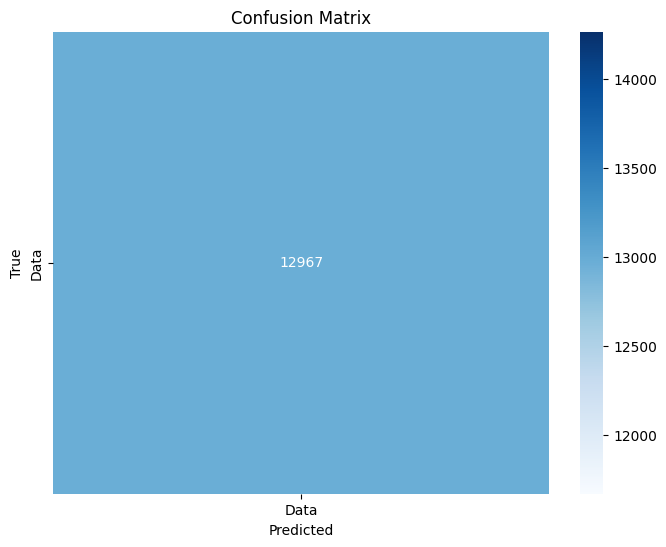

In [18]:
evaluate(model, test_loader, device, dataset.classes)

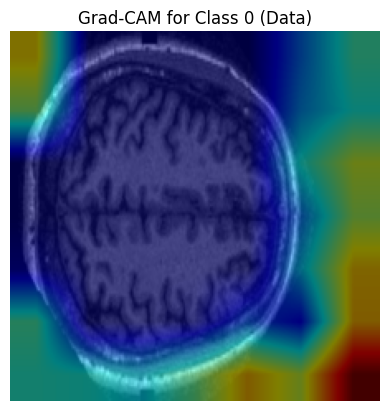

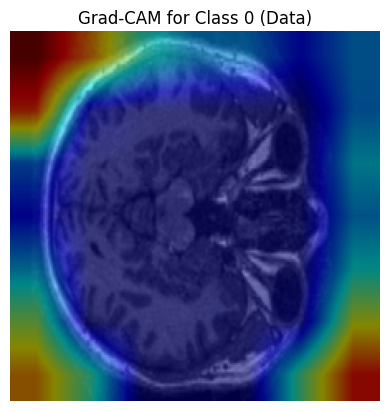

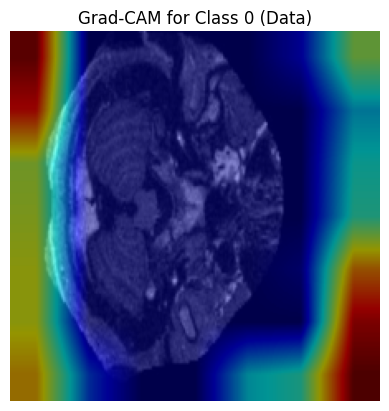

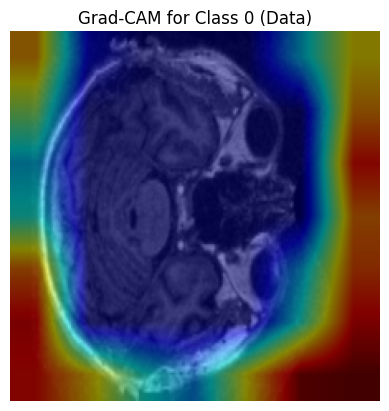

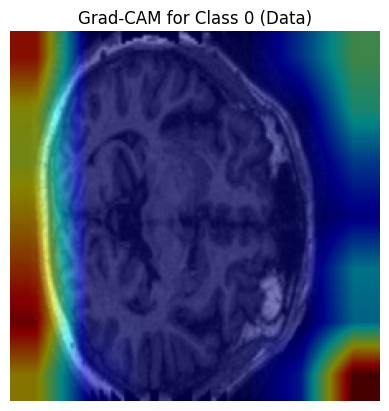

In [19]:
run_gradcam(model, test_loader, dataset.classes, device)

In [20]:
pip install lime shap scikit-image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=b35978745ee7c88086c0d449bad8de666b047dd112ed7cb57dbafeb2bbf6cd92
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [21]:
# LIME imports
from lime.lime_image import LimeImageExplainer
from skimage.segmentation import mark_boundaries

# SHAP import
import shap

  0%|          | 0/100 [00:00<?, ?it/s]

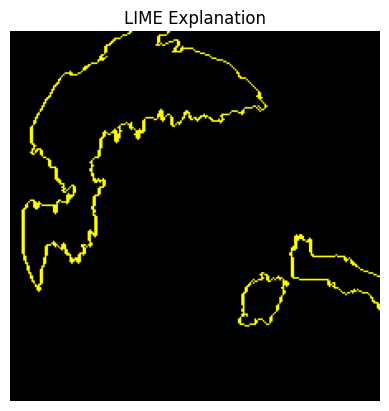

Background shape: torch.Size([10, 3, 224, 224])
Test images shape: torch.Size([5, 3, 224, 224])


SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (5, 3, 224, 224, 3)


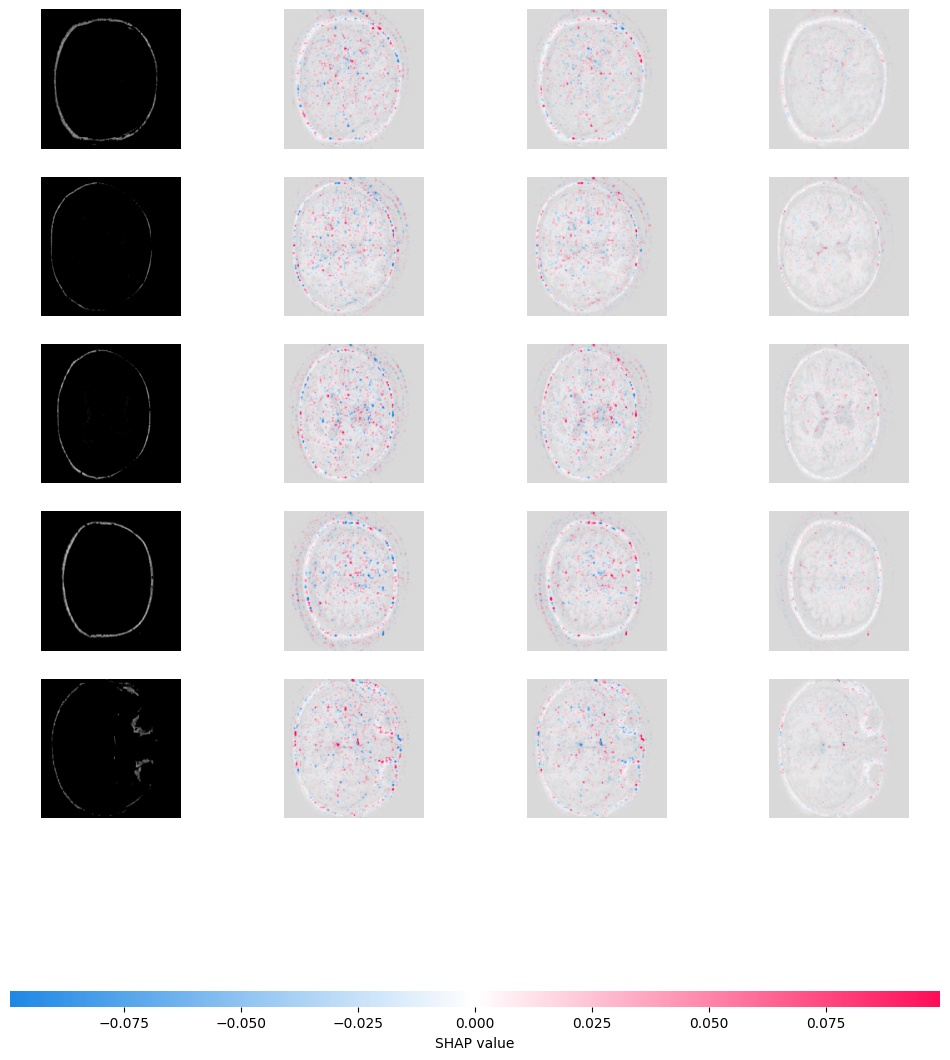

In [22]:
# ---------------------- LIME Explanation ----------------------
def run_lime(model, dataloader, device, transform):
    model.eval()
    explainer = LimeImageExplainer()

    def batch_predict(images):
        # images are numpy arrays from LIME, convert to tensor and apply transform
        batch = torch.stack([transform(transforms.ToPILImage()(img)) for img in images], dim=0).to(device)
        with torch.no_grad():
            outputs = model(batch)
        return outputs.cpu().numpy()

    images, labels = next(iter(dataloader))
    explanation = explainer.explain_instance(
        images[0].permute(1, 2, 0).cpu().numpy(),
        batch_predict,
        top_labels=1, hide_color=0, num_samples=100
    )
    temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, hide_rest=False)
    plt.imshow(mark_boundaries(temp / 255.0, mask))
    plt.title("LIME Explanation")
    plt.axis('off')
    plt.show()

def run_shap(model, dataloader, device):
    model.eval()
    images, _ = next(iter(dataloader))
    background = images[:10].to(device)
    test_images = images[10:15].to(device)

    print("Background shape:", background.shape)
    print("Test images shape:", test_images.shape)

    explainer = shap.GradientExplainer(model, background)
    shap_values = explainer.shap_values(test_images)

    print("SHAP values type:", type(shap_values))
    print("SHAP values shape:", shap_values.shape)

    # shap_values shape: (batch, classes, height, width, channels)
    # Split along axis=1 (classes) and convert each to (batch, height, width, channels)
    shap_values_per_class = [shap_values[:, i, :, :, :] for i in range(shap_values.shape[1])]

    # Convert test images to channels-last for plotting
    test_images_np = test_images.cpu().numpy().transpose(0, 2, 3, 1)

    shap.image_plot(shap_values_per_class, test_images_np)


# ---------------------- Run Explainability ----------------------
run_lime(model, test_loader, device, transform)
run_shap(model, test_loader, device)

# ---------------------- Save Model ----------------------
torch.save(model.state_dict(), "cnn_transformer_hybrid.pth")

In [23]:
def run_lime_save(model, dataloader, device, transform):
    model.eval()
    explainer = LimeImageExplainer()
    images, labels = next(iter(dataloader))

    def batch_predict(images):
        batch = torch.stack([transform(transforms.ToPILImage()(img)) for img in images], dim=0).to(device)
        with torch.no_grad():
            outputs = model(batch)
        return outputs.cpu().numpy()

    explanation = explainer.explain_instance(
        images[0].permute(1, 2, 0).cpu().numpy(),
        batch_predict,
        top_labels=1, hide_color=0, num_samples=100
    )
    temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, hide_rest=False)

    img = mark_boundaries(temp / 255.0, mask)
    img = np.clip(img, 0, 1)  # <-- Clip values before saving

    plt.imsave('lime_explanation.png', img)
    print("Saved LIME explanation to lime_explanation.png")

run_lime_save(model, test_loader, device, transform)

  0%|          | 0/100 [00:00<?, ?it/s]

Saved LIME explanation to lime_explanation.png


In [24]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])


In [25]:
from sklearn.metrics import classification_report

def evaluate_full_report(model, dataloader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(classification_report(all_labels, all_preds, target_names=class_names))

evaluate_full_report(model, test_loader, device, dataset.classes)


              precision    recall  f1-score   support

        Data       1.00      1.00      1.00     12967

    accuracy                           1.00     12967
   macro avg       1.00      1.00      1.00     12967
weighted avg       1.00      1.00      1.00     12967



In [26]:
example_input = torch.randn(1, 3, 224, 224).to(device)
traced_script_module = torch.jit.trace(model, example_input)
traced_script_module.save("cnn_transformer_hybrid_script.pt")
print("Model saved as TorchScript.")


Model saved as TorchScript.


In [27]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the saved TorchScript model
loaded_model = torch.jit.load("cnn_transformer_hybrid_script.pt").to(device)
loaded_model.eval()

# Create a dummy input tensor with the same shape your model expects
example_input = torch.randn(1, 3, 224, 224).to(device)

# Run inference
with torch.no_grad():
    output = loaded_model(example_input)

print("Inference output:", output)


Inference output: tensor([[ 5.0275, -2.2057, -1.9903]], device='cuda:0')


In [29]:
from PIL import Image
import torchvision.transforms as transforms
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define your transforms (example)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Full path to the GIF file
image_path = r"/content/OAS1_0308_MR1_mpr-1_anon_sag_66.gif"

# Load the GIF, convert to RGB
image = Image.open(image_path).convert("RGB")

# Apply transforms
input_tensor = transform(image).unsqueeze(0).to(device)

print("Image tensor shape:", input_tensor.shape)

Image tensor shape: torch.Size([1, 3, 224, 224])


In [ ]:
import torch
from torchvision import transforms
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load TorchScript model
model = torch.jit.load("cnn_transformer_hybrid_script.pt").to(device)
model.eval()

# Define transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Load and preprocess your GIF image
image_path = r"/content/OAS1_0001_MR1_mpr_n4_anon_111_t88_masked_gfc_fseg_tra_90.gif"
image = Image.open(image_path).convert("RGB")

input_tensor = transform(image).unsqueeze(0).to(device)

# Run inference
with torch.no_grad():
    output = model(input_tensor)

predicted_class = torch.argmax(output, dim=1).item()
print(f"Predicted class index: {predicted_class}")


Predicted class index: 0


In [ ]:
predicted_class = torch.argmax(output, dim=1).item()

class_names = ["Healthy", "Alzheimer's", "Other"]  # Change this to your classes
predicted_label = class_names[predicted_class]

print(f"Predicted class index: {predicted_class}")
print(f"Predicted label: {predicted_label}")

Predicted class index: 0
Predicted label: Healthy


In [30]:
import torch
from torchvision import transforms
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load TorchScript model
model = torch.jit.load("cnn_transformer_hybrid_script.pt").to(device)
model.eval()

# Define transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Load and preprocess your GIF image
image_path = r"/content/OAS1_0308_MR1_mpr-1_anon_sag_66.gif"
image = Image.open(image_path).convert("RGB")

input_tensor = transform(image).unsqueeze(0).to(device)

# Run inference
with torch.no_grad():
    output = model(input_tensor)

predicted_class = torch.argmax(output, dim=1).item()

# Map class index to human-readable label
class_names = ["Healthy", "Alzheimer's", "Other"]  # update as needed
predicted_label = class_names[predicted_class]

print(f"Predicted class index: {predicted_class}")
print(f"Predicted label: {predicted_label}")

Predicted class index: 0
Predicted label: Healthy


July 15th code

In [31]:
import zipfile
import os

with zipfile.ZipFile("extracted_images.zip", 'r') as zip_ref:
    zip_ref.extractall("images")

# Check contents
os.listdir("images")


['extracted_images']

In [32]:
import pandas as pd

metadata = pd.read_excel("meta-data.xlsx")
print(metadata.head())

# Filter out entries without CDR
metadata = metadata[metadata["CDR"].notna()]


              ID M/F Hand  Age  Educ  SES  MMSE  CDR  eTIV   nWBV    ASF  \
0  OAS1_0001_MR1   F    R   74   2.0  3.0  29.0  0.0  1344  0.743  1.306   
1  OAS1_0002_MR1   F    R   55   4.0  1.0  29.0  0.0  1147  0.810  1.531   
2  OAS1_0003_MR1   F    R   73   4.0  3.0  27.0  0.5  1454  0.708  1.207   
3  OAS1_0004_MR1   M    R   28   NaN  NaN   NaN  NaN  1588  0.803  1.105   
4  OAS1_0005_MR1   M    R   18   NaN  NaN   NaN  NaN  1737  0.848  1.010   

   Delay  
0    NaN  
1    NaN  
2    NaN  
3    NaN  
4    NaN  


In [33]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch

# Transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# Dataset
dataset = datasets.ImageFolder("images", transform=transform)


In [34]:
from collections import Counter
import torch.nn as nn

targets = [label for _, label in dataset]
class_counts = Counter(targets)
print("Class counts:", class_counts)

weights = torch.tensor([
    1.0 / class_counts.get(i, 1) for i in range(len(dataset.classes))
], dtype=torch.float)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss(weight=weights.to(device))


Class counts: Counter({0: 2144})


In [35]:
from torch.utils.data import random_split, WeightedRandomSampler

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])

# Optional: Oversample
targets = [dataset.targets[i] for i in train_ds.indices]
class_sample_count = Counter(targets)
sample_weights = [1.0 / class_sample_count[t] for t in targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)


In [36]:
# Training loop
def train(model, train_loader, val_loader, criterion, optimizer, epochs=2):
    for epoch in range(epochs):
        model.train()
        train_loss, correct = 0.0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

        train_acc = correct / len(train_loader.dataset)

        # Validation
        model.eval()
        val_correct = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")


In [37]:
# Test function
def test(model, test_loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            correct += (outputs.argmax(1) == labels).sum().item()
    accuracy = correct / len(test_loader.dataset)
    print(f"Test Accuracy: {accuracy:.4f}")


In [40]:
# ============================
# Alzheimer's Disease Detection Using CNN-Transformer Hybrid
# Fully Updated with Local Dataset + Metadata Integration
# ============================

import os
import zipfile
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
from torch import nn, optim
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
from torchvision import datasets, transforms, models
from torchvision.models import resnet18, ResNet18_Weights
from lime.lime_image import LimeImageExplainer
from skimage.segmentation import mark_boundaries
import shap

In [41]:

# ========== Step 3: Define Transforms ==========
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

In [42]:
# ========== Step 4: Load Dataset ==========
dataset = datasets.ImageFolder("images", transform=transform)
class_names = dataset.classes

targets = [label for _, label in dataset]
class_counts = Counter(targets)
weights = torch.tensor([
    1.0 / class_counts.get(i, 1) for i in range(len(class_names))
], dtype=torch.float)

In [43]:
# ========== Step 5: Split Dataset ==========
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])


In [44]:
# ========== Step 6: Weighted Sampling ==========
train_targets = [dataset.targets[i] for i in train_ds.indices]
class_sample_count = Counter(train_targets)
sample_weights = [1.0 / class_sample_count[t] for t in train_targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

In [46]:
# ========== Step 7: Define CNN + Transformer Model ==========
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim), nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + attn_out)
        x = self.norm2(x + self.mlp(x))
        return x
class CNNTransformerHybrid(nn.Module):
    def __init__(self, num_classes=3, embed_dim=512, num_heads=8, mlp_dim=2048, num_layers=1):
        super().__init__()
        resnet = resnet18(weights=ResNet18_Weights.DEFAULT)
        self.cnn = nn.Sequential(*list(resnet.children())[:-2])
        self.flatten = nn.Flatten(2)
        self.transpose = lambda x: x.permute(2, 0, 1)
        self.transformer = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim) for _ in range(num_layers)
        ])
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim), nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        x = self.transpose(self.flatten(self.cnn(x)))
        for layer in self.transformer:
            x = layer(x)
        return self.head(x.mean(dim=0))

In [47]:
# ========== Step 8: Training, Evaluation, Testing ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNTransformerHybrid(num_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss(weight=weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def train(model, train_loader, val_loader, criterion, optimizer, epochs=2):
    for epoch in range(epochs):
        model.train(); train_loss, correct = 0.0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward(); optimizer.step()
            train_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
        train_acc = correct / len(train_loader.dataset)
        val_acc = sum((model(x.to(device)).argmax(1) == y.to(device)).sum().item()
                      for x, y in val_loader) / len(val_loader.dataset)
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

def test(model, test_loader):
    model.eval(); correct = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            correct += (outputs.argmax(1) == labels).sum().item()
    print(f"Test Accuracy: {correct / len(test_loader.dataset):.4f}")

In [48]:
# ========== Step 9: Explainability ==========
def run_lime(model, dataloader):
    model.eval(); explainer = LimeImageExplainer()
    images, _ = next(iter(dataloader))
    def batch_predict(images):
        batch = torch.stack([transform(transforms.ToPILImage()(img)) for img in images], dim=0).to(device)
        with torch.no_grad(): outputs = model(batch)
        return outputs.cpu().numpy()
    explanation = explainer.explain_instance(
        images[0].permute(1, 2, 0).numpy(), batch_predict, top_labels=1, hide_color=0, num_samples=100
    )
    temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, hide_rest=False)
    plt.imshow(mark_boundaries(temp / 255.0, mask))
    plt.title("LIME Explanation"); plt.axis('off'); plt.show()

def run_shap(model, dataloader):
    model.eval()
    images, _ = next(iter(dataloader))
    background, test_images = images[:10].to(device), images[10:15].to(device)
    explainer = shap.GradientExplainer(model, background)
    shap_values = explainer.shap_values(test_images)
    test_images_np = test_images.cpu().numpy().transpose(0, 2, 3, 1)
    shap.image_plot([shap_values[:, i, :, :, :] for i in range(shap_values.shape[1])], test_images_np)

def evaluate(model, dataloader):
    model.eval(); all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            outputs = model(images.to(device))
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    print(classification_report(all_labels, all_preds, target_names=class_names))
    sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix"); plt.show()


Epoch 1: Train Loss=0.0000, Train Acc=1.0000, Val Acc=1.0000
Epoch 2: Train Loss=0.0000, Train Acc=1.0000, Val Acc=1.0000
Epoch 3: Train Loss=0.0000, Train Acc=1.0000, Val Acc=1.0000
Epoch 4: Train Loss=0.0000, Train Acc=1.0000, Val Acc=1.0000
Epoch 5: Train Loss=0.0000, Train Acc=1.0000, Val Acc=1.0000
Epoch 6: Train Loss=0.0000, Train Acc=1.0000, Val Acc=1.0000
Epoch 7: Train Loss=0.0000, Train Acc=1.0000, Val Acc=1.0000
Epoch 8: Train Loss=0.0000, Train Acc=1.0000, Val Acc=1.0000
Epoch 9: Train Loss=0.0000, Train Acc=1.0000, Val Acc=1.0000
Epoch 10: Train Loss=0.0000, Train Acc=1.0000, Val Acc=1.0000
Test Accuracy: 1.0000
                  precision    recall  f1-score   support

extracted_images       1.00      1.00      1.00       323

        accuracy                           1.00       323
       macro avg       1.00      1.00      1.00       323
    weighted avg       1.00      1.00      1.00       323



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


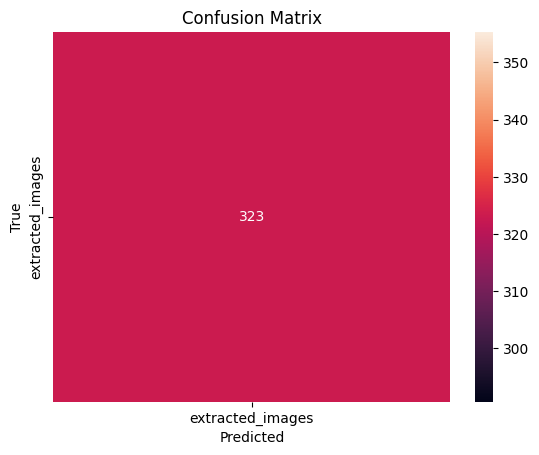

  0%|          | 0/100 [00:00<?, ?it/s]

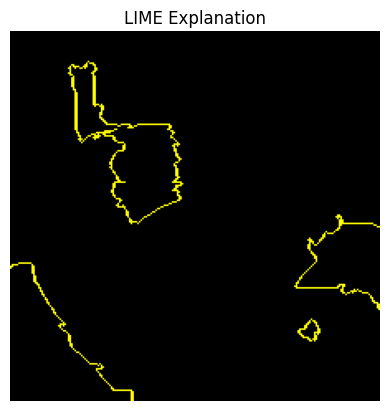

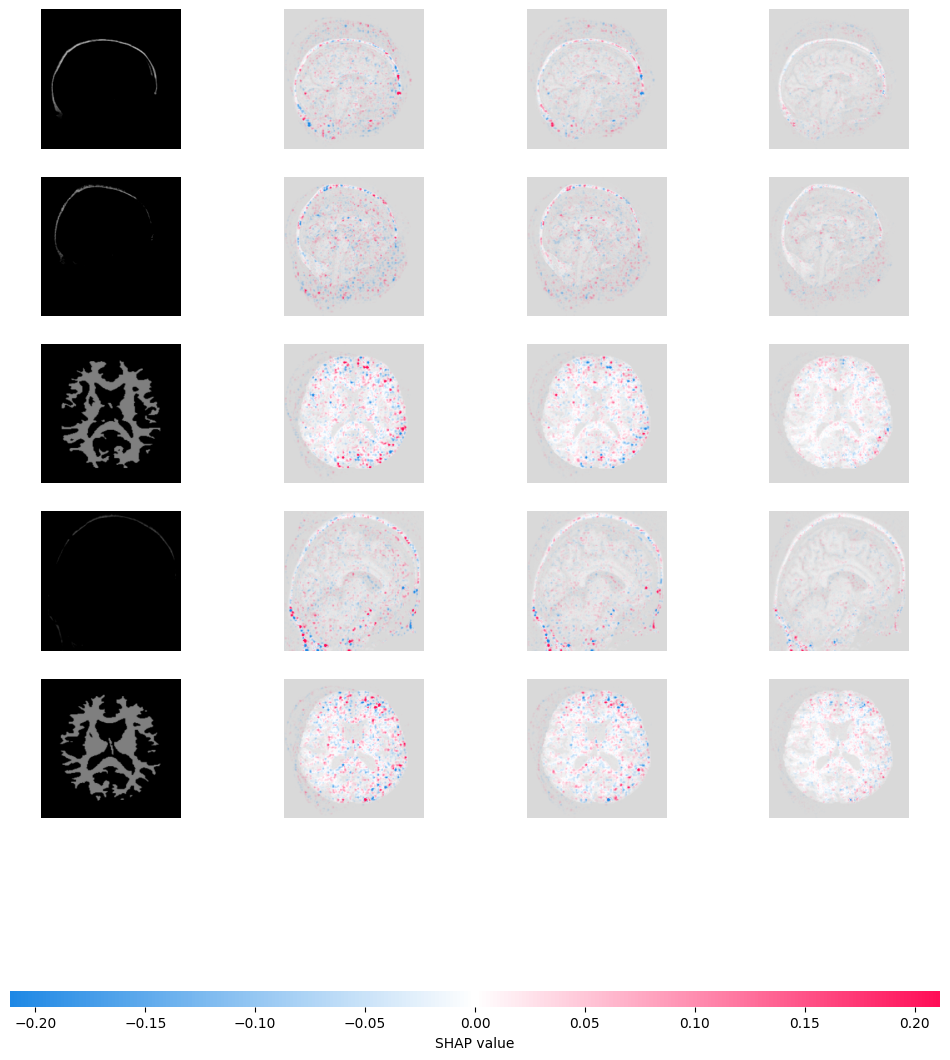

In [50]:
# ========== Step 10: Run Everything ==========
train(model, train_loader, val_loader, criterion, optimizer, epochs=10)
test(model, test_loader)
evaluate(model, test_loader)
run_lime(model, test_loader)
run_shap(model, test_loader)

In [51]:
# Save TorchScript
example_input = torch.randn(1, 3, 224, 224).to(device)
torch.jit.trace(model, example_input).save("cnn_transformer_hybrid_script.pt")
print("Model saved as TorchScript.")


Model saved as TorchScript.


In [52]:
import torch
from torchvision import transforms
from PIL import Image

# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the trained TorchScript model
model = torch.jit.load("cnn_transformer_hybrid_script.pt").to(device)
model.eval()

# Define the same transform used during training
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Define class names (update based on your dataset)
class_names = ["Healthy", "Mild Cognitive Impairment", "Dementia"]

def predict_mri_image(image_path):
    # Load and preprocess image
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    # Run inference
    with torch.no_grad():
        output = model(input_tensor)
        predicted_index = torch.argmax(output, dim=1).item()
        predicted_label = class_names[predicted_index]

    print(f"✅ Prediction: {predicted_label} (Class {predicted_index})")
    return predicted_label


In [53]:
# Example: Replace path with your actual MRI image file path (e.g., JPG, PNG, or GIF)
mri_path = "/content/OAS1_0308_MR1_mpr-1_anon_sag_66.gif"
predict_mri_image(mri_path)

✅ Prediction: Healthy (Class 0)


'Healthy'

In [55]:
!pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.7 MB/s eta 0:00:00


In [56]:
import os
import zipfile
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from torchvision.models import resnet18, ResNet18_Weights
from captum.attr import LayerGradCam, LayerAttribution, visualization as viz
from lime.lime_image import LimeImageExplainer
from skimage.segmentation import mark_boundaries
import shap

# ========== 1. Extract images & load metadata ==========

metadata = pd.read_excel("meta-data.xlsx")
metadata = metadata[metadata["CDR"].notna()].copy()
metadata["CDR"] = metadata["CDR"].astype(str)

feature_cols = ["Age", "Educ", "SES", "MMSE", "eTIV", "nWBV", "ASF"]
metadata = metadata.dropna(subset=feature_cols)
metadata[feature_cols] = metadata[feature_cols].astype(float)

scaler = StandardScaler()
metadata[feature_cols] = scaler.fit_transform(metadata[feature_cols])
metadata = metadata.set_index("ID")

# ========== 2. Multi‑modal Dataset ==========

class MRIWithMetadataDataset(Dataset):
    def __init__(self, root_dir, metadata, transform):
        self.transform = transform
        self.image_paths, self.meta_features, self.labels = [], [], []
        class_map = {"0": 0, "0.5": 1, "2": 2}
        for cls in os.listdir(root_dir):
            for f in os.listdir(os.path.join(root_dir, cls)):
                if f.endswith(".gif"):
                    img_id = f.split("_mpr")[0]
                    if img_id in metadata.index:
                        cdr = metadata.loc[img_id, "CDR"]
                        if cdr in class_map:
                            self.image_paths.append(os.path.join(root_dir, cls, f))
                            self.meta_features.append(metadata.loc[img_id, feature_cols].values.astype(np.float32))
                            self.labels.append(class_map[cdr])
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        img = Image.open(self.image_paths[i]).convert("RGB")
        img = self.transform(img)
        return img, torch.tensor(self.meta_features[i]), self.labels[i]

transform = transforms.Compose([
    transforms.Resize((224, 224)), transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

dataset = MRIWithMetadataDataset("images", metadata, transform)
class_names = ["Healthy", "Mild Dementia", "Moderate Dementia"]

train_size = int(0.7*len(dataset))
val_size = int(0.15*len(dataset))
test_size = len(dataset) - train_size - val_size
train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16)
test_loader  = DataLoader(test_ds, batch_size=16)

# ========== 3. Model Definition ==========

class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, heads, dropout=dropout)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
    def forward(self, x):
        a,_ = self.attn(x,x,x)
        x = self.norm1(x + a)
        x = self.norm2(x + self.mlp(x))
        return x

class CNNTransformerWithMeta(nn.Module):
    def __init__(self, meta_dim, num_classes=3):
        super().__init__()
        res = resnet18(weights=ResNet18_Weights.DEFAULT)
        self.cnn = nn.Sequential(*list(res.children())[:-2])
        self.flatten = nn.Flatten(2)
        self.trans = TransformerEncoderBlock(embed_dim=512, heads=8, mlp_dim=2048)
        self.meta_fc = nn.Sequential(nn.Linear(meta_dim, 64), nn.ReLU(), nn.Linear(64, 64))
        self.fusion = nn.Sequential(nn.Linear(512+64, 128), nn.ReLU(), nn.Linear(128, num_classes))
    def forward(self, img, meta):
        x = self.cnn(img)     # B x 512 x 7 x 7
        x = self.flatten(x)   # B x 512 x 49
        x = x.permute(2,0,1)  # 49 x B x 512
        x = self.trans(x)
        img_feat = x.mean(dim=0)
        meta_feat = self.meta_fc(meta)
        return self.fusion(torch.cat([img_feat, meta_feat], dim=1))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNTransformerWithMeta(meta_dim=len(feature_cols)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# ========== 4. Training & Evaluation ==========

def train(epochs=5):
    for ep in range(1, epochs+1):
        model.train()
        tloss, correct = 0,0
        for img, meta, lab in train_loader:
            img, meta, lab = img.to(device), meta.to(device), lab.to(device)
            optimizer.zero_grad()
            out = model(img,meta)
            loss = criterion(out,lab)
            loss.backward()
            optimizer.step()
            tloss += loss.item()
            correct += (out.argmax(1)==lab).sum().item()
        print(f"Epoch {ep}: Loss {tloss:.4f}, Acc {correct/len(train_ds):.4f}")
train()

def evaluate(loader):
    model.eval()
    all_p, all_l = [],[]
    with torch.no_grad():
        for img, meta, lab in loader:
            out = model(img.to(device), meta.to(device))
            preds = out.argmax(1).cpu().numpy()
            all_p.extend(preds); all_l.extend(lab.numpy())
    print(classification_report(all_l, all_p, target_names=class_names))
    sns.heatmap(confusion_matrix(all_l, all_p), annot=True, fmt='d',
                xticklabels=class_names, yticklabels=class_names)
    plt.show()
evaluate(test_loader)

# ========== 5. Explainability Module ==========

model.eval()

# --- 5.1 Grad-CAM (captum on final CNN layer) ---
target_layer = model.cnn[-1]  # final conv layer
gc = LayerGradCam(model, target_layer)

def show_gradcam(img_tensor, label):
    img = img_tensor.unsqueeze(0).to(device)
    attr = gc.attribute(img, target=label)
    up = LayerAttribution.interpolate(attr, img.shape[2:])
    viz.visualize_image_attr(up[0].cpu().permute(1,2,0).detach().numpy(), img_tensor.permute(1,2,0).numpy(),
                             method="heat_map", title="Grad‑CAM")

# --- 5.2 LIME ---
lime_exp = LimeImageExplainer()

def show_lime(img_tensor):
    def batch_pred(images):
        imgs = torch.stack([transform(transforms.ToPILImage()(i)) for i in images], dim=0).to(device)
        with torch.no_grad(): outs = model(imgs, torch.zeros((len(images), len(feature_cols))).to(device))
        return np.exp(outs.cpu().numpy())  # softmax-like
    img_np = img_tensor.permute(1,2,0).numpy()
    exp = lime_exp.explain_instance(img_np, batch_pred, top_labels=1, hide_color=0, num_samples=100)
    tmp, mask = exp.get_image_and_mask(exp.top_labels[0], positive_only=True, hide_rest=False)
    plt.imshow(mark_boundaries(tmp/255., mask)); plt.title("LIME"); plt.axis('off'); plt.show()

# --- 5.3 SHAP -->
shap_bg = next(iter(train_loader))[0][:10].to(device)
shap_exp = shap.GradientExplainer((lambda x,y: model(x, y=torch.zeros(x.size(0), len(feature_cols)).to(device))), shap_bg)

def show_shap(img_tensor):
    tv = img_tensor.unsqueeze(0).to(device)
    vals = shap_exp.shap_values(tv)  # list: one per class
    shap.image_plot(vals, tv.cpu().permute(0,2,3,1).numpy())

# ========== 6. Run Explanations on Test Sample ==========
img0, meta0, lab0 = next(iter(test_loader))
print("True label:", class_names[lab0.item()])

show_gradcam(img0, lab0.item())
show_lime(img0)
show_shap(img0)


ValueError: num_samples should be a positive integer value, but got num_samples=0

Total samples loaded: 2144
Starting training...
Epoch 1/5 — Loss: 0.5699
Epoch 2/5 — Loss: 0.2702
Epoch 3/5 — Loss: 0.1884
Epoch 4/5 — Loss: 0.0990
Epoch 5/5 — Loss: 0.0587
True label: 0


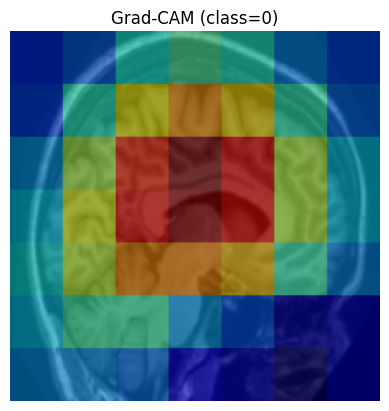

  0%|          | 0/200 [00:00<?, ?it/s]

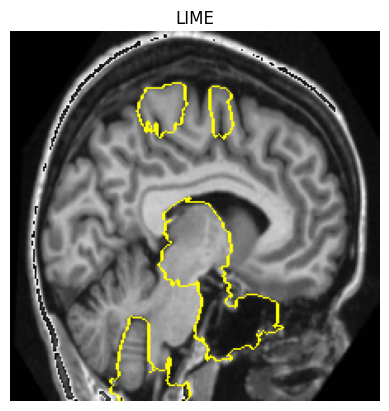

In [78]:
# Alzheimer’s MRI Classification with Metadata Fusion (Age, CDR, MMSE)
# Includes: CNN + Metadata Fusion, Grad‑CAM, LIME, SHAP

import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image

from captum.attr import LayerGradCam, LayerAttribution
from lime.lime_image import LimeImageExplainer
from skimage.segmentation import mark_boundaries
import shap

# ======== Constants ========
IMG_ROOT    = "images/extracted_images"   # your pre‑extracted folder
META_FILE   = "meta-data.xlsx"            # your Excel metadata file
BATCH_SIZE  = 16
NUM_EPOCHS  = 5
LEARNING_RATE = 1e-4

# ======== Step 1: Dataset Class with Metadata ========
class AlzheimerDataset(Dataset):
    def __init__(self, excel_file, image_folder, transform=None):
        self.data = pd.read_excel(excel_file)
        self.data['label'] = (self.data['CDR'] > 0).astype(int)
        self.transform = transform
        self.samples = []

        for root, _, files in os.walk(image_folder):
            for fname in files:
                if fname.lower().endswith((".gif",".png",".jpg",".jpeg")):
                    # <-- split on "_mpr" instead of "_"
                    img_id = fname.split("_mpr")[0]
                    row = self.data[self.data['ID'] == img_id]
                    if not row.empty:
                        meta_vals = row[['Age','CDR','MMSE']].iloc[0].values.astype(np.float32)
                        lbl       = int(row['label'].iloc[0])
                        self.samples.append((os.path.join(root, fname), meta_vals, lbl))

        self.samples.sort()

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, meta_vals, lbl = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        meta = torch.tensor(meta_vals, dtype=torch.float32)
        lbl  = torch.tensor(lbl, dtype=torch.long)
        return img, meta, lbl

# ======== Step 2: Model Definition ========
class CNNWithMetadata(nn.Module):
    def __init__(self, metadata_dim, num_classes=2):
        super().__init__()
        self.cnn = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.cnn.fc = nn.Identity()
        self.meta_fc = nn.Sequential(
            nn.Linear(metadata_dim, 16),
            nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Linear(512 + 16, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, img, meta):
        img_feat  = self.cnn(img)
        meta_feat = self.meta_fc(meta)
        x = torch.cat([img_feat, meta_feat], dim=1)
        return self.classifier(x)

# ======== Step 3: Data Prep ========
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

dataset = AlzheimerDataset(META_FILE, IMG_ROOT, transform=transform)
print(f"Total samples loaded: {len(dataset)}")

# Split
n = len(dataset)
train_n = int(0.7*n)
val_n   = int(0.15*n)
test_n  = n - train_n - val_n
train_ds, val_ds, test_ds = random_split(dataset, [train_n, val_n, test_n])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds, batch_size=1)

# ======== Step 4: Train ========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = CNNWithMetadata(metadata_dim=3, num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("Starting training...")
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for imgs, metas, labels in train_loader:
        imgs, metas, labels = imgs.to(device), metas.to(device), labels.to(device)
        optimizer.zero_grad()
        outs = model(imgs, metas)
        loss = criterion(outs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} — Loss: {running_loss/len(train_loader):.4f}")

# ======== Step 5: Explainability ========
def show_grad_cam(model, image, metadata, target_class):
    model.eval()
    cam = LayerGradCam(model, model.cnn.layer4)
    # Compute Grad‑CAM attribution for the specific class
    attr = cam.attribute(
        image.unsqueeze(0).to(device),
        target=target_class,
        additional_forward_args=metadata.unsqueeze(0).to(device)
    )
    # Upsample to image size
    up = LayerAttribution.interpolate(attr, image.shape[1:])
    # Squeeze batch dim and average over channel dim -> (H, W)
    heatmap = up.squeeze(0).mean(dim=0).cpu().detach().numpy()

    # Overlay on original image (denormalize for display)
    img_np = image.cpu().permute(1,2,0).numpy() * 0.5 + 0.5
    plt.imshow(img_np)
    plt.imshow(heatmap, cmap='jet', alpha=0.5)
    plt.title(f"Grad‑CAM (class={target_class})")
    plt.axis('off')
    plt.show()

def show_lime(model, image, metadata):
    explainer = LimeImageExplainer()
    def batch_pred(imgs_np):
        imgs = torch.stack([transform(Image.fromarray(im)) for im in imgs_np]).to(device)
        metas = metadata.unsqueeze(0).repeat(len(imgs),1).to(device)
        with torch.no_grad():
            preds = model(imgs, metas)
        return torch.softmax(preds, dim=1).cpu().numpy()

    img_np = np.array(transforms.ToPILImage()(image.cpu()))
    exp   = explainer.explain_instance(img_np, batch_pred, top_labels=1,
                                        hide_color=0, num_samples=200)
    temp, mask = exp.get_image_and_mask(exp.top_labels[0],
                                        positive_only=True, num_features=5)
    plt.imshow(mark_boundaries(temp/255.0, mask))
    plt.title("LIME"); plt.axis('off'); plt.show()

# ======== Step 8: SHAP (wrapped nn.Module) ========
import torch.nn as nn

class ImageOnlyWrapper(nn.Module):
    def __init__(self, full_model, fixed_meta):
        super().__init__()
        self.full_model = full_model
        # Register fixed_meta as a buffer so it's moved with .to(device)
        self.register_buffer("fixed_meta", fixed_meta)

    def forward(self, img):
        # full_model expects (img, meta)
        meta_batch = self.fixed_meta[: img.shape[0]]
        return self.full_model(img, meta_batch)

def show_shap(model, image, metadata):
    model.eval()

    # 1) Define a numpy-based prediction function
    def f(imgs_np):
        # imgs_np: (N, H, W, C) uint8 or float in [0,1]
        # Convert to tensor: (N, C, H, W)
        imgs_t = torch.from_numpy(imgs_np).permute(0,3,1,2).float().to(device)
        # Normalize using your transform
        imgs_t = torch.stack([transform(Image.fromarray((im * 255).astype(np.uint8)))
                              for im in imgs_np], dim=0).to(device)
        metas = metadata.unsqueeze(0).repeat(imgs_t.size(0),1).to(device)
        with torch.no_grad():
            logits = model(imgs_t, metas)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
        return probs

    # 2) Prepare data for KernelExplainer
    # Get a small “background” of 10 images (we just tile the single image)
    orig_np = np.array(transforms.ToPILImage()(image.cpu())) / 255.0
    bg = np.stack([orig_np for _ in range(10)], axis=0)

    # 3) Create the explainer
    explainer = shap.KernelExplainer(f, bg)

    # 4) Compute SHAP values on just the one image
    shap_vals = explainer.shap_values(orig_np[np.newaxis, ...])

    # 5) Plot the explanation for the predicted class
    pred = model(image.unsqueeze(0).to(device),
                 metadata.unsqueeze(0).to(device)).argmax(1).item()
    shap.image_plot(shap_vals[pred], [orig_np])


# ======== Running it on the first test sample ========
img, meta, lbl = test_ds[0]
img, meta = img.to(device), meta.to(device)

print("True label:", lbl.item())
# Pass lbl.item() as the target to Grad‑CAM:
show_grad_cam(model, img, meta, target_class=lbl.item())
show_lime(model, img, meta)
# show_shap(model, img, meta)


Total samples loaded: 2144
Starting training with accuracy tracking...
Epoch 1/5 — Loss: 0.5705, Train Acc: 0.7940, Val Acc: 0.7227
Epoch 2/5 — Loss: 0.3389, Train Acc: 0.9193, Val Acc: 0.7788
Epoch 3/5 — Loss: 0.2340, Train Acc: 0.9760, Val Acc: 0.8474
Epoch 4/5 — Loss: 0.1481, Train Acc: 0.9840, Val Acc: 0.8567
Epoch 5/5 — Loss: 0.0636, Train Acc: 0.9960, Val Acc: 0.8598

Test Accuracy: 0.8700

              precision    recall  f1-score   support

     Healthy       0.88      0.89      0.89       187
    Dementia       0.85      0.84      0.84       136

    accuracy                           0.87       323
   macro avg       0.87      0.87      0.87       323
weighted avg       0.87      0.87      0.87       323



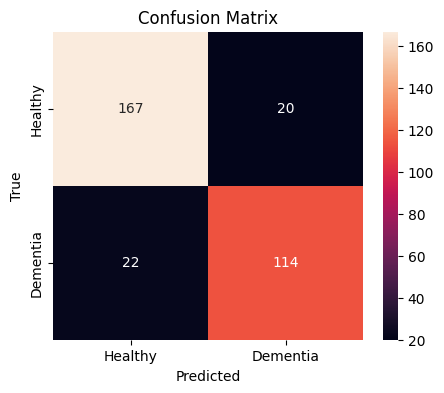

True label for explanation sample: 0


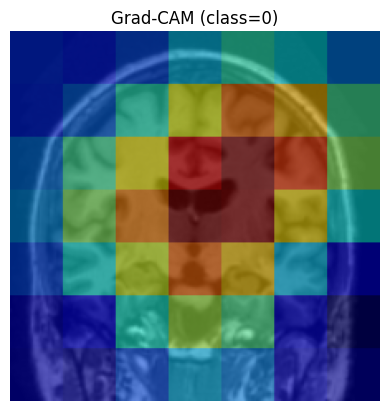

  0%|          | 0/200 [00:00<?, ?it/s]

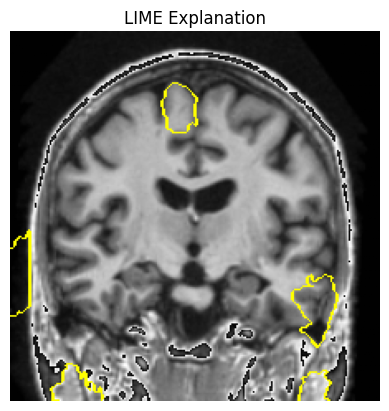

In [80]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image

from captum.attr import LayerGradCam, LayerAttribution
from lime.lime_image import LimeImageExplainer
from skimage.segmentation import mark_boundaries

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ======== Constants ========
IMG_ROOT      = "images/extracted_images"   # pre‑extracted folder
META_FILE     = "meta-data.xlsx"            # Excel metadata file
BATCH_SIZE    = 16
NUM_EPOCHS    = 5
LEARNING_RATE = 1e-4
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======== 1) Dataset Definition ========
class AlzheimerDataset(Dataset):
    def __init__(self, excel_file, image_root, transform=None):
        md = pd.read_excel(excel_file)
        md['label'] = (md['CDR'] > 0).astype(int)
        self.transform = transform
        self.samples = []
        for root, _, files in os.walk(image_root):
            for fname in files:
                if fname.lower().endswith((".gif",".png",".jpg",".jpeg")):
                    img_id = fname.split("_mpr")[0]
                    row = md[md['ID'] == img_id]
                    if not row.empty:
                        meta_vals = row[['Age','CDR','MMSE']].iloc[0].values.astype(np.float32)
                        lbl       = int(row['label'].iloc[0])
                        self.samples.append((os.path.join(root, fname), meta_vals, lbl))
        self.samples.sort()

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, meta_vals, lbl = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        meta = torch.tensor(meta_vals, dtype=torch.float32)
        lbl  = torch.tensor(lbl, dtype=torch.long)
        return img, meta, lbl

# ======== 2) Model Definition ========
class CNNWithMetadata(nn.Module):
    def __init__(self, metadata_dim, num_classes=2):
        super().__init__()
        self.cnn = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.cnn.fc = nn.Identity()
        self.meta_fc = nn.Sequential(
            nn.Linear(metadata_dim, 16),
            nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Linear(512 + 16, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, img, meta):
        img_feat  = self.cnn(img)
        meta_feat = self.meta_fc(meta)
        x = torch.cat([img_feat, meta_feat], dim=1)
        return self.classifier(x)

# ======== 3) Transforms & DataLoaders ========
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

dataset = AlzheimerDataset(META_FILE, IMG_ROOT, transform=transform)
print(f"Total samples loaded: {len(dataset)}")

n = len(dataset)
train_n = int(0.7 * n)
val_n   = int(0.15 * n)
test_n  = n - train_n - val_n
train_ds, val_ds, test_ds = random_split(dataset, [train_n, val_n, test_n])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds, batch_size=1)

# ======== 4) Instantiate Model, Loss, Optimizer ========
model     = CNNWithMetadata(metadata_dim=3, num_classes=2).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ======== 5) Training with Metrics ========
print("Starting training with accuracy tracking...")
for epoch in range(NUM_EPOCHS):
    # --- Training ---
    model.train()
    running_loss = 0.0
    for imgs, metas, labels in train_loader:
        imgs, metas, labels = imgs.to(DEVICE), metas.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outs = model(imgs, metas)
        loss = criterion(outs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # --- Compute train & val accuracy ---
    def compute_acc(loader):
        model.eval()
        y_true, y_pred = [], []
        with torch.no_grad():
            for imgs, metas, labels in loader:
                imgs, metas = imgs.to(DEVICE), metas.to(DEVICE)
                outs = model(imgs, metas)
                preds = outs.argmax(1).cpu().tolist()
                y_true.extend(labels.tolist())
                y_pred.extend(preds)
        return accuracy_score(y_true, y_pred)

    train_acc = compute_acc(train_loader)
    val_acc   = compute_acc(val_loader)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} — "
          f"Loss: {running_loss/len(train_loader):.4f}, "
          f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

# ======== 6) Final Test‐Set Evaluation ========
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for imgs, metas, labels in test_loader:
        imgs, metas = imgs.to(DEVICE), metas.to(DEVICE)
        outs = model(imgs, metas)
        preds = outs.argmax(1).cpu().tolist()
        y_true.extend(labels.tolist())
        y_pred.extend(preds)

test_acc = accuracy_score(y_true, y_pred)
print(f"\nTest Accuracy: {test_acc:.4f}\n")
print(classification_report(y_true, y_pred, target_names=["Healthy","Dementia"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Healthy","Dementia"],
            yticklabels=["Healthy","Dementia"])
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
plt.show()

# ======== 7) Explanation on First Test Sample ========
# Grab one sample
img, meta, lbl = test_ds[0]
img, meta = img.to(DEVICE), meta.to(DEVICE)
print("True label for explanation sample:", lbl.item())

# Grad‑CAM
def show_grad_cam(model, image, metadata, target_class):
    model.eval()
    cam = LayerGradCam(model, model.cnn.layer4)
    attr = cam.attribute(
        image.unsqueeze(0),
        target=target_class,
        additional_forward_args=metadata.unsqueeze(0)
    )
    up = LayerAttribution.interpolate(attr, image.shape[1:])
    heat = up.squeeze(0).mean(0).cpu().detach().numpy()
    img_np = image.cpu().permute(1,2,0).numpy() * 0.5 + 0.5
    plt.imshow(img_np); plt.imshow(heat, cmap='jet', alpha=0.5)
    plt.title(f"Grad‑CAM (class={target_class})"); plt.axis('off'); plt.show()

show_grad_cam(model, img, meta, lbl.item())

# LIME
def show_lime(model, image, metadata):
    explainer = LimeImageExplainer()
    def batch_pred(imgs_np):
        imgs = torch.stack([transform(Image.fromarray(im)) for im in imgs_np]).to(DEVICE)
        metas = metadata.unsqueeze(0).repeat(len(imgs),1).to(DEVICE)
        with torch.no_grad():
            preds = model(imgs, metas)
        return torch.softmax(preds, dim=1).cpu().numpy()

    img_np = np.array(transforms.ToPILImage()(image.cpu()))
    exp   = explainer.explain_instance(img_np, batch_pred,
                                        top_labels=1, hide_color=0,
                                        num_samples=200)
    temp, mask = exp.get_image_and_mask(
        exp.top_labels[0], positive_only=True, num_features=5
    )
    plt.imshow(mark_boundaries(temp/255.0, mask))
    plt.title("LIME Explanation"); plt.axis('off'); plt.show()

show_lime(model, img, meta)